## 留意事項
- 本資料は教育・情報提供を目的としたもので、特定銘柄の売買推奨ではありません。
- バックテスト結果は将来成果を保証しません。
- 実運用は自己責任で行ってください。

# 先物乖離 Part 2-4: 上場タイミングとワースト分析

**目的**
* 前回たまたま当たった銘柄探しから、再現性のある戦略設計に落とし込む

**やること**
- 宿題1: 全362銘柄を対象に、上場後14〜59日（2か月以内）の累積損益曲線を作って、全体の傾向を確認する。
- 宿題2: 成績が下位20銘柄を取り出し、負け方を分解して「なぜ負けたか」の共通パターンを深掘りする。

**分析区間の補足**
- 最初の有効データは上場後14日（day14）です。
day0〜13は、z-score（14日ローリング）を前日値で当日シグナルに使う計算仕様上、有効な損益をまだ算出できないため、分析対象から除外しています。

**前提**
- 同梱されたCSVを使って再現します
- API取得は行いません


---
## 環境設定
分析に必要なライブラリと共通処理を読み込みます。

In [115]:
# 任意: japanize-matplotlib を使う場合のみ有効化してください。
# !pip install japanize-matplotlib -q

import importlib
import os
import subprocess
import sys
from pathlib import Path
from typing import Optional

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.ft2font import FT2Font
import numpy as np
import pandas as pd


def _font_supports_japanese(font_path: str, sample: str = "日本語上場分析") -> bool:
    """指定フォントに日本語グリフが含まれるかを簡易判定する。"""
    try:
        ft = FT2Font(font_path)
        return all(ft.get_char_index(ord(ch)) != 0 for ch in sample)
    except Exception:
        return False


def _pick_local_japanese_font() -> Optional[str]:
    """環境内フォントから日本語表示可能な候補を優先順で選ぶ。"""
    priority_keywords = [
        "IPAexGothic",
        "IPAGothic",
        "Noto Sans CJK JP",
        "Noto Sans JP",
        "Source Han Sans",
        "Hiragino Sans",
        "Yu Gothic",
        "Meiryo",
        "MS Gothic",
        "TakaoGothic",
    ]

    candidates = []
    for f in fm.fontManager.ttflist:
        name = str(f.name)
        fpath = str(getattr(f, "fname", ""))
        if not fpath:
            continue
        if _font_supports_japanese(fpath):
            candidates.append((name, fpath))

    if not candidates:
        return None

    lowered = [(n, p, n.lower()) for n, p in candidates]
    for kw in priority_keywords:
        kw_l = kw.lower()
        for name, _, n_l in lowered:
            if kw_l in n_l:
                return name

    return candidates[0][0]


def setup_japanese_font() -> Optional[str]:
    """日本語文字化け対策: japanize優先、なければローカル日本語フォントを探索。"""
    mpl.rcParams["axes.unicode_minus"] = False

    # 1) 既にjapanizeが使える場合
    try:
        import japanize_matplotlib  # noqa: F401
        return "japanize-matplotlib"
    except Exception:
        pass

    # 2) OSにある日本語フォントを使う
    local_font = _pick_local_japanese_font()
    if local_font:
        mpl.rcParams["font.family"] = "sans-serif"
        mpl.rcParams["font.sans-serif"] = [local_font, *mpl.rcParams.get("font.sans-serif", [])]
        return local_font

    # 3) 最後にjapanizeを自動導入（ネットワーク/権限で失敗する場合あり）
    try:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "japanize-matplotlib"],
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        importlib.invalidate_caches()
        import japanize_matplotlib  # noqa: F401
        return "japanize-matplotlib(installed)"
    except Exception:
        return None


def enforce_japanese_font_fallback() -> Optional[str]:
    """既知の日本語フォントを優先して強制設定する最終フォールバック。"""
    preferred = [
        "Hiragino Sans",
        "Hiragino Kaku Gothic ProN",
        "Yu Gothic",
        "YuGothic",
        "Meiryo",
        "MS Gothic",
        "Noto Sans CJK JP",
        "Noto Sans JP",
        "IPAexGothic",
        "IPAGothic",
    ]
    available = {str(f.name) for f in fm.fontManager.ttflist}
    current = list(mpl.rcParams.get("font.sans-serif", []))
    for name in preferred:
        if name in available:
            mpl.rcParams["font.family"] = [name, "sans-serif"]
            mpl.rcParams["font.sans-serif"] = [name, *current]
            mpl.rcParams["axes.unicode_minus"] = False
            return name
    return None


plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# 明示フォント優先 -> 自動探索の順で設定
font_name = enforce_japanese_font_fallback() or setup_japanese_font()
if font_name:
    print("日本語フォント設定:", font_name)
else:
    print(
        "警告: 日本語フォントを特定できませんでした。"
        " グラフ文字化け時は `pip install japanize-matplotlib` または OSフォント導入を実施してください。"
    )


def find_analysis_dir() -> Path:
    """配布先に依存しないよう、相対探索で analysis ディレクトリを見つける。"""
    env_dir = os.environ.get("HOMEWORK_ANALYSIS_DIR")
    if env_dir:
        c = Path(env_dir).expanduser()
        if (c / "homework_report_common.py").exists():
            return c.resolve()

    candidates: list[Path] = []
    seen: set[Path] = set()
    for base in [Path.cwd(), *Path.cwd().parents]:
        for c in [base, base / "analyses" / "20260322_1430_futures_basis_homework_share"]:
            r = c.resolve()
            if r not in seen:
                seen.add(r)
                candidates.append(r)

    for c in candidates:
        if (c / "homework_report_common.py").exists():
            return c

    raise FileNotFoundError(
        "homework_report_common.py が見つかりません。"
        " ノートと同じフォルダに配置するか、HOMEWORK_ANALYSIS_DIR を指定してください。"
    )


ANALYSIS_DIR = find_analysis_dir()
CSV_OUT_DIR = ANALYSIS_DIR / "csv"
CSV_OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from homework_report_common import (
    export_artifacts,
    plot_curve_eventday,
    plot_curve_month_snapshot,
    plot_paired_diff_hist,
    plot_window_median_sharpe,
    plot_worst_curves,
    build_worst_summary_table,
    print_final_homework_answer,
    run_homework_report,
)

print("ANALYSIS_DIR found:", ANALYSIS_DIR.name)
print("CSV_OUT_DIR ready:", "csv/")


日本語フォント設定: Hiragino Sans
ANALYSIS_DIR found: 20260322_1430_futures_basis_homework_share
CSV_OUT_DIR ready: csv/


---
## 入力データ読み込み
ここでは同梱CSVを読み込みます。APIは使いません。

In [ ]:
def find_csv_dir() -> Path:
    candidates = [
        ANALYSIS_DIR / "csv",
        Path("./csv"),
        Path("../csv"),
    ]

    req_primary = ["homework_input_summary.csv", "homework_input_daily.csv"]
    req_legacy = ["altcoin_basis_hw_summary.csv", "altcoin_basis_hw_daily_pnl_all.csv"]

    for c in candidates:
        if all((c / f).exists() for f in req_primary):
            return c.resolve()
    for c in candidates:
        if all((c / f).exists() for f in req_legacy):
            return c.resolve()

    raise FileNotFoundError(
        "入力CSVが見つかりません。配布パッケージの csv フォルダを確認してください。"
    )


CSV_DIR = find_csv_dir()

summary_primary = CSV_DIR / "homework_input_summary.csv"
daily_primary = CSV_DIR / "homework_input_daily.csv"

summary_legacy = CSV_DIR / "altcoin_basis_hw_summary.csv"
daily_legacy = CSV_DIR / "altcoin_basis_hw_daily_pnl_all.csv"

if summary_primary.exists() and daily_primary.exists():
    summary_df = pd.read_csv(summary_primary)
    daily_df = pd.read_csv(daily_primary)
    INPUT_SOURCE_LABEL = "csv:homework_input"
else:
    summary_df = pd.read_csv(summary_legacy)
    daily_df = pd.read_csv(daily_legacy)
    INPUT_SOURCE_LABEL = "csv:legacy_hw"

print("CSV_DIR:", CSV_DIR)
print("INPUT_SOURCE_LABEL:", INPUT_SOURCE_LABEL)
print("summary rows:", len(summary_df), "daily rows:", len(daily_df))


ここでは、宿題1・2の集計をまとめて作成します。
`artifacts` は「この後のグラフ・表・結論に使う結果セット」です。

In [117]:
REPORT_CONFIG = {
    "curve_start_day": 14,
    "curve_end_day": 59,
    "month1_end_day": 29,
    "month2_end_day": 59,
    "worst_n": 20,
    "min_obs": 20,
    "win_rate_threshold_pct": 55.0,
    "input_source": INPUT_SOURCE_LABEL,
}

artifacts = run_homework_report(summary_df, daily_df, REPORT_CONFIG)

print("集計が完了しました。")
print(f"- 入力ソース: {INPUT_SOURCE_LABEL}")
print(f"- 対象銘柄数: {artifacts['input_summary']['symbol'].nunique()}銘柄")
print(f"- 日次データ件数: {len(artifacts['input_daily']):,}行")
print(f"- 上場後2ヶ月以内（day14-59）の分析対象件数: {len(artifacts['curve_symbol_daily']):,}行")
print("- 補足: z-scoreを14日ローリングで算出し、前日z-scoreで当日シグナルを出す仕様のため、最初の有効データはday14です")


集計が完了しました。
- 入力ソース: csv:homework_input
- 対象銘柄数: 362銘柄
- 日次データ件数: 326,012行
- 上場後2ヶ月以内（day14-59）の分析対象件数: 16,652行
- 補足: z-scoreを14日ローリングで算出し、前日z-scoreで当日シグナルを出す仕様のため、最初の有効データはday14です


---
## 入力データ確認
対象銘柄数や期間など、分析の前提が正しいか確認します。

In [118]:
display(artifacts["input_summary"].head(5))
print("=" * 60)
print("[入力サマリー]")
summary_rows = len(artifacts["input_summary"])
summary_symbols = artifacts["input_summary"]["symbol"].nunique()
censored = int(artifacts["input_summary"]["is_listing_censored"].sum())
print("- 行数:", summary_rows)
print("- 銘柄数:", summary_symbols)
print("- 上場時点不明（censored）:", censored)

print("\n[日次データ]")
daily_rows = len(artifacts["input_daily"])
daily_symbols = artifacts["input_daily"]["symbol"].nunique()
event_min = int(artifacts["input_daily"]["event_day"].min())
event_max = int(artifacts["input_daily"]["event_day"].max())
print("- 行数:", daily_rows)
print("- 銘柄数:", daily_symbols)
print("- event_day 範囲:", event_min, "〜", event_max)

print(
    f"\nこの表からわかること: 分析対象は{summary_symbols}銘柄で、"
    f"日次データも{daily_symbols}銘柄ぶん揃っているため、全体比較が可能です。"
)


,symbol,data_days,start_date,end_date,spot_listed_at,perp_listed_at,listing_trade_start,is_listing_censored,avg_volume_usd,corr_zscore_next,return_gross,sharpe_gross,win_gross,dd_gross,return_net,sharpe_net,win_net,dd_net,n_trades,turnover_pct,total_cost
0,MORPHO,171,2025-10-03,2026-03-22,2025-10-03T00:00:00+00:00,2024-11-27T00:00:00+00:00,2025-10-03T00:00:00+00:00,False,1.288066e+07,-0.159292,1.291890,3.222931,59.235669,-0.307484,1.237890,3.088540,57.961783,-0.312284,68,43.312102,0.0540
1,KMNO,321,2025-05-06,2026-03-22,2025-05-06T00:00:00+00:00,2024-12-20T00:00:00+00:00,2025-05-06T00:00:00+00:00,False,2.800200e+06,-0.081524,2.823471,3.193724,55.048860,-0.298846,2.708671,3.065671,55.048860,-0.304446,144,46.905537,0.1148
2,TRUMP,428,2025-01-19,2026-03-22,2025-01-19T00:00:00+00:00,2025-01-18T00:00:00+00:00,2025-01-19T00:00:00+00:00,False,1.498036e+08,-0.110457,3.890711,3.031756,56.521739,-0.424613,3.720711,2.899642,56.521739,-0.437413,213,51.449275,0.1700
3,NIL,364,2025-03-24,2026-03-22,2025-03-24T00:00:00+00:00,2025-03-24T00:00:00+00:00,2025-03-24T00:00:00+00:00,False,4.980652e+06,-0.115506,3.407589,2.760738,54.571429,-0.613557,3.272789,2.651276,54.285714,-0.629557,169,48.285714,0.1348
4,SYRUP,320,2025-05-07,2026-03-22,2025-05-06T00:00:00+00:00,2025-05-07T00:00:00+00:00,2025-05-07T00:00:00+00:00,False,1.336308e+07,-0.100290,2.354979,2.714708,55.228758,-0.419390,2.234579,2.576532,54.901961,-0.431390,151,49.346405,0.1204


[入力サマリー]
- 行数: 362
- 銘柄数: 362
- 上場時点不明（censored）: 59

[日次データ]
- 行数: 326012
- 銘柄数: 362
- event_day 範囲: 14 〜 1907

この表からわかること: 分析対象は362銘柄で、日次データも362銘柄ぶん揃っているため、全体比較が可能です。


---
## 宿題1: 上場後2ヶ月以内の損益曲線（分析区間: event_day 14-59）
※ `event_day` は「上場日を0日目とした経過日数」です。
※ day0-13を外している理由: z-score(14日)を前日値で当日シグナルに使う仕様上、最初の有効損益がday14からになるためです。
### 1. 代表曲線（中央値 + 分位帯）
全銘柄を同じ基準日でそろえて、損益の流れを確認します。
※ 補足: この図は1銘柄ずつの線ではなく、全銘柄の分布を要約した図です（青=中央値、橙=平均、帯=25-75%/10-90%）。


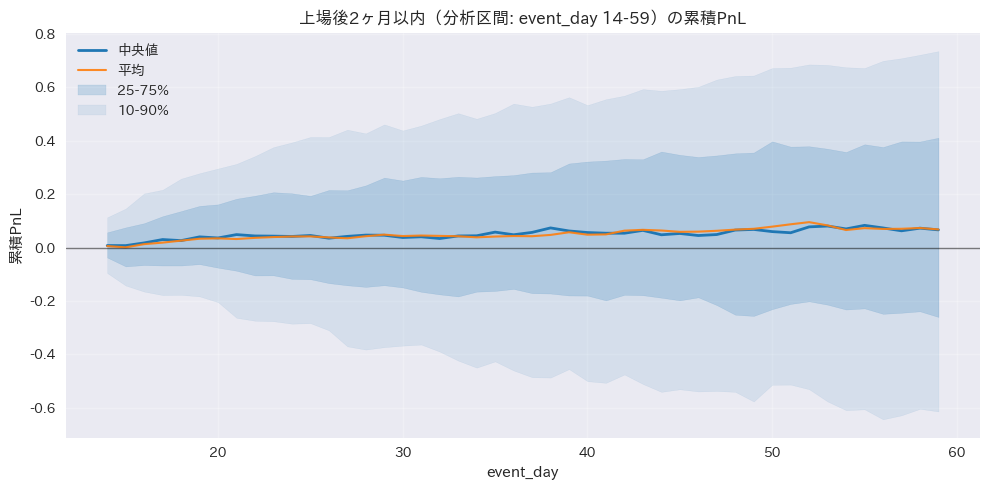

このグラフからわかること: 中央値は期間全体で上向き（+0.0076 → +0.0662）ですが、銘柄差の幅（10-90%）は最終日で約1.348と大きく、銘柄ごとの差が大きいです。
補足: 1銘柄ごとの線ではなく、全銘柄をevent_dayでそろえた分布要約（中央値・平均・分位帯）です。


In [119]:
fig = plot_curve_eventday(artifacts)
plt.show()

curve = artifacts["curve_eventday_summary"].copy().sort_values("event_day")
start_med = float(curve["median"].iloc[0])
end_med = float(curve["median"].iloc[-1])
spread_end = float(curve["q90"].iloc[-1] - curve["q10"].iloc[-1])
trend = "上向き" if end_med > start_med else "横ばい〜下向き"

print(
    f"このグラフからわかること: 中央値は期間全体で{trend}（{start_med:+.4f} → {end_med:+.4f}）ですが、"
    f"銘柄差の幅（10-90%）は最終日で約{spread_end:.3f}と大きく、銘柄ごとの差が大きいです。"
)

print("補足: 1銘柄ごとの線ではなく、全銘柄をevent_dayでそろえた分布要約（中央値・平均・分位帯）です。")


評価の仕方（基準がないとき）は、中央値との相対比較が有効。


1.348 / 0.066 ≒ 20.4倍
つまり「全体の真ん中の優位性（+0.066）」より、銘柄間ばらつきの方が圧倒的に大きいことがわかる。

### 2. 1ヶ月目と2ヶ月目の比較
上場1ヶ月目と2ヶ月目で、損益分布がどう変わるかを比較します。

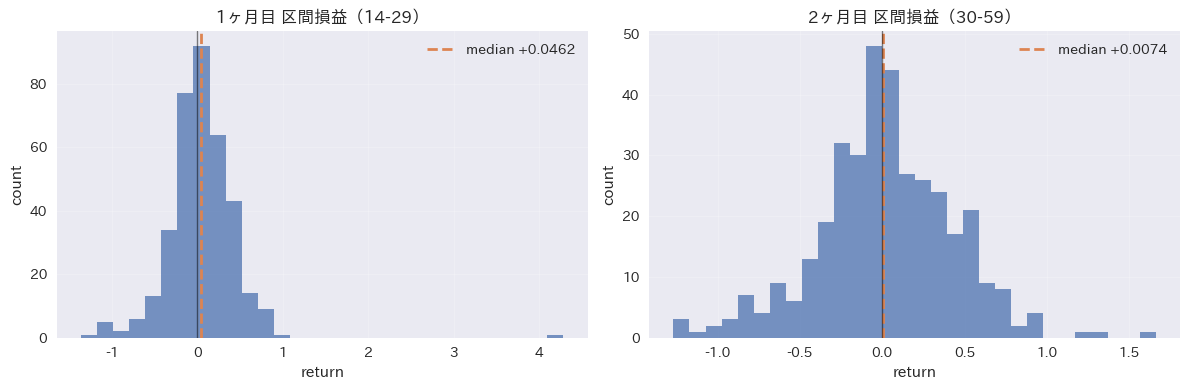

,symbol,ret_m1_14_29,ret_m2_30_59,cum_m2_end_14_59,is_listing_censored
0,0G,0.377350,0.475677,0.853027,False
1,1000CAT,0.096440,0.719016,0.815455,False
2,1000CHEEMS,0.318398,0.449623,0.768021,False
3,1000SATS,0.154488,-0.022783,0.131705,False
4,1INCH,0.696214,-1.114834,-0.418620,True
5,1MBABYDOGE,-0.063432,-0.239860,-0.303292,False
6,2Z,-0.105283,-0.303348,-0.408630,False
7,A,0.151324,-0.231126,-0.079802,False
8,A2Z,0.602402,0.517926,1.120327,False
9,AAVE,0.683544,0.478923,1.162466,True


この結果からわかること: 上場1ヶ月目の中央値は+0.0462、2ヶ月目は+0.0074で、1ヶ月目の方が高い水準でした。


In [120]:
fig = plot_curve_month_snapshot(artifacts)
plt.show()

month_df = artifacts["curve_symbol_month"].copy()
display(month_df.head(10))

m1_med = float(month_df["ret_m1_14_29"].median())
m2_med = float(month_df["ret_m2_30_59"].median())
rel = "高い" if m1_med > m2_med else "低い"

print(
    f"この結果からわかること: 上場1ヶ月目の中央値は{m1_med:+.4f}、2ヶ月目は{m2_med:+.4f}で、"
    f"1ヶ月目の方が{rel}水準でした。"
)


---
## 宿題1の追加確認: 期間ごとの成績比較
上場後の区間ごとに、成績の違いを確認します。

※ サンプル定義（3つのパネルの意味）
- `S_all`: 全銘柄（上場時点の欠損有無を問わない）
- `S_nc`: 上場時点が欠損していない銘柄のみ（`is_listing_censored=False`）
- `S_180`: `S_all` のうち、day150-179区間で30日以上データがある銘柄（長期比較が可能な群）


* S_all: 362銘柄
* S_nc: 303銘柄
* S_180: 339銘柄

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


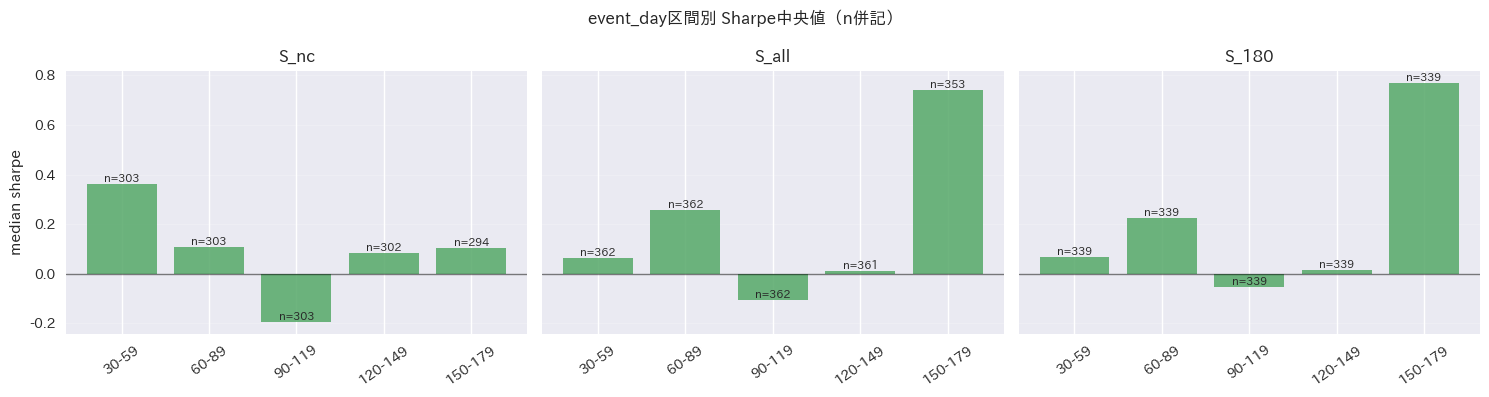

,sample_set,window,n_symbols,n_valid_sharpe,n_full_30,median_sharpe,mean_sharpe,iqr_sharpe,median_return
0,S_all,14-29,362,0,0,NaN,NaN,NaN,0.046197
1,S_all,30-59,362,362,362,0.064783,0.214780,4.671192,0.007398
2,S_all,60-89,362,362,362,0.257990,0.096079,4.412909,0.029945
3,S_all,90-119,362,362,361,-0.104486,-0.025970,4.688466,-0.012260
4,S_all,120-149,361,356,353,0.010429,0.148908,5.099178,0.004125
5,S_all,150-179,353,346,339,0.742199,0.607941,5.246447,0.057745
6,S_nc,14-29,303,0,0,NaN,NaN,NaN,0.030788
7,S_nc,30-59,303,303,303,0.362381,0.479412,4.798418,0.024104
8,S_nc,60-89,303,303,303,0.106252,0.022418,4.746095,0.010214
9,S_nc,90-119,303,303,302,-0.193592,-0.053443,4.728227,-0.019483


このグラフからわかること: S_nc基準では early平均=+0.234, late平均=+0.095 で、上場初期が後半より良い傾向です。


In [121]:
fig = plot_window_median_sharpe(artifacts)
plt.show()

window_summary = artifacts["window_summary"].copy()
display(window_summary)

s_nc = window_summary[window_summary["sample_set"] == "S_nc"].copy()
early = s_nc[s_nc["window"].isin(["30-59", "60-89"])]["median_sharpe"].mean()
late = s_nc[s_nc["window"].isin(["120-149", "150-179"])]["median_sharpe"].mean()

if pd.notna(early) and pd.notna(late):
    if early > late:
        msg = "上場初期が後半より良い傾向"
    elif early < late:
        msg = "上場後半の方が良い傾向"
    else:
        msg = "初期と後半で差が小さい傾向"
    print(
        f"このグラフからわかること: S_nc基準では early平均={early:+.3f}, late平均={late:+.3f} で、{msg}です。"
    )


### 3. 同じ銘柄で「上場初期と後半」を比較
銘柄ごとに、上場初期の方が有利だったかを確認します。

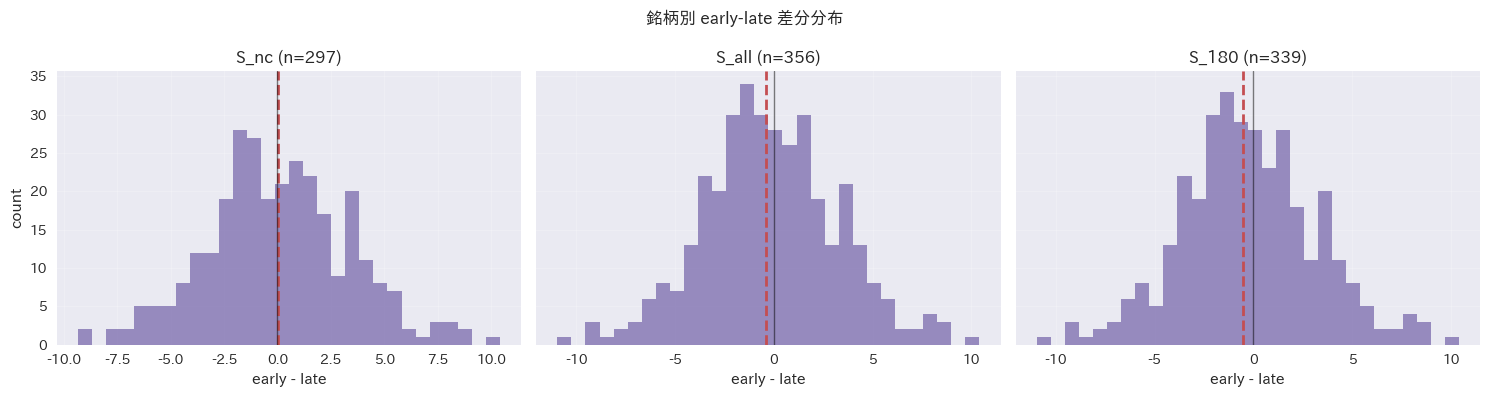

,sample_set,n_pairs,wins,win_rate_diff,median_diff,mean_diff,sign_test_pvalue
0,S_all,356,165,46.348315,-0.396322,-0.199091,0.923835
1,S_nc,297,149,50.168350,0.015600,0.094253,0.500000
2,S_180,339,153,45.132743,-0.496806,-0.255996,0.967679


この結果からわかること: 同一銘柄比較では中央値差が+0.0156、初期が勝った割合は50.17%で、全体としては初期優位寄りです。


In [122]:
fig = plot_paired_diff_hist(artifacts)
plt.show()

paired_stats = artifacts["paired_stats"].copy()
display(paired_stats)

s_nc = paired_stats[paired_stats["sample_set"] == "S_nc"]
if len(s_nc) > 0:
    row = s_nc.iloc[0]
    median_diff = float(row["median_diff"])
    win_rate = float(row["win_rate_diff"])
    direction = "初期優位" if median_diff > 0 else "後半優位"
    print(
        f"この結果からわかること: 同一銘柄比較では中央値差が{median_diff:+.4f}、"
        f"初期が勝った割合は{win_rate:.2f}%で、全体としては{direction}寄りです。"
    )


---
## 宿題2: ワースト銘柄の深掘り
成績が悪かった銘柄の特徴と負け方を確認します。

In [123]:
worst_df = artifacts["worst_diagnostics"].copy()
required_cols = {"primary_loss_type", "loss_tags", "peak_to_trough_days", "peak_cum_net"}

if not required_cols.issubset(worst_df.columns):
    # まずは最新版ロジックで再集計を試す（成功すれば最も正確）
    try:
        import importlib
        import homework_report_common as _hrc

        _hrc = importlib.reload(_hrc)
        if {"summary_df", "daily_df", "REPORT_CONFIG"}.issubset(globals()):
            artifacts = _hrc.run_homework_report(summary_df, daily_df, REPORT_CONFIG)
            worst_df = artifacts["worst_diagnostics"].copy()
            print("[補足] 旧形式データを検出したため、最新版ロジックで再集計しました。")
    except Exception as e:
        print(f"[補足] 再集計に失敗したため、互換補完で続行します: {e}")


def _ensure_primary_loss_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 旧フォーマット互換: 追加列がない場合はここで補完する
    if "primary_loss_type" not in out.columns:
        legacy_map = {
            "逆張り不適合型": "方向不一致型",
            "恒常負け型": "その他",
            "テール損失集中型": "テール主導型",
            "コスト負け型": "コスト負け型",
        }
        if "failure_type" in out.columns:
            out["primary_loss_type"] = out["failure_type"].map(legacy_map).fillna(out["failure_type"])
        else:
            out["primary_loss_type"] = "その他"

    for c in ["corr_zscore_next", "tail_loss_ratio", "peak_to_trough_days", "peak_cum_net"]:
        if c not in out.columns:
            out[c] = np.nan

    if "loss_tags" not in out.columns:
        def _mk_tags(r: pd.Series) -> str:
            tags = []
            if pd.notna(r["corr_zscore_next"]) and r["corr_zscore_next"] > 0:
                tags.append("方向不一致")
            if pd.notna(r["tail_loss_ratio"]) and r["tail_loss_ratio"] >= 0.5:
                tags.append("テール主導")
            if (
                pd.notna(r["peak_to_trough_days"]) and pd.notna(r["tail_loss_ratio"]) and
                (r["peak_to_trough_days"] >= 90) and (r["tail_loss_ratio"] < 0.5)
            ):
                tags.append("じわじわ下落")
            if pd.notna(r["peak_cum_net"]) and r["peak_cum_net"] <= 0:
                tags.append("初期から苦戦")
            return "/".join(tags if tags else ["その他"])

        out["loss_tags"] = out.apply(_mk_tags, axis=1)

    return out


worst_df = _ensure_primary_loss_columns(worst_df)

display(worst_df[[
    "symbol", "sharpe_gross", "sharpe_net", "return_net", "dd_net",
    "worst_1d_net", "worst_5d_net", "tail_loss_ratio", "is_cost_killed",
    "primary_loss_type", "loss_tags"
]])

print("主因タイプの内訳（1銘柄1ラベル）")
main_counts = worst_df["primary_loss_type"].value_counts()
print(main_counts)

tag_stats = pd.Series({
    "方向不一致": (worst_df["corr_zscore_next"] > 0).mean() * 100,
    "テール主導": (worst_df["tail_loss_ratio"] >= 0.5).mean() * 100,
    "じわじわ下落": ((worst_df["peak_to_trough_days"] >= 90) & (worst_df["tail_loss_ratio"] < 0.5)).mean() * 100,
    "初期から苦戦": (worst_df["peak_cum_net"] <= 0).mean() * 100,
}).round(2)

print("\n補助タグ率（重複可）")
for k, v in tag_stats.items():
    print(f"- {k}: {v:.2f}%")

if len(main_counts) > 0:
    top_type = main_counts.index[0]
    top_count = int(main_counts.iloc[0])
    print(
        f"この表からわかること: 主因タイプの中心は『{top_type}』で、"
        f"{top_count}/{len(worst_df)}銘柄を占めています。"
    )


,symbol,sharpe_gross,sharpe_net,return_net,dd_net,worst_1d_net,worst_5d_net,tail_loss_ratio,is_cost_killed,primary_loss_type,loss_tags
0,DOLO,-2.409800,-2.482389,-2.076353,-2.416122,-0.720156,-0.963647,0.464106,False,じわじわ下落型,方向不一致/じわじわ下落
1,FORM,-2.230387,-2.295651,-3.078633,-3.828823,-0.463058,-0.696242,0.226153,False,じわじわ下落型,方向不一致/じわじわ下落
2,ALLO,-2.101222,-2.195613,-0.939763,-1.168663,-0.271272,-0.471528,0.501752,False,テール主導型,方向不一致/テール主導
3,SAPIEN,-2.089913,-2.161007,-1.200517,-1.569265,-0.710242,-0.912085,0.759744,False,テール主導型,方向不一致/テール主導
4,YB,-2.018544,-2.130616,-1.045688,-0.886939,-0.177797,-0.392730,0.375571,False,初期から苦戦型,じわじわ下落/初期から苦戦
5,TOWNS,-1.967351,-2.065411,-1.459767,-1.696293,-0.232025,-0.423578,0.290168,False,じわじわ下落型,方向不一致/じわじわ下落
6,RARE,-1.941066,-2.058167,-3.807392,-3.871850,-0.474405,-0.866327,0.227538,False,じわじわ下落型,方向不一致/じわじわ下落
7,MITO,-1.882754,-1.983425,-1.465201,-1.729860,-0.365040,-0.709061,0.483934,False,じわじわ下落型,方向不一致/じわじわ下落
8,EUL,-1.851809,-1.947229,-1.017220,-1.060733,-0.256188,-0.448963,0.441362,False,じわじわ下落型,方向不一致/じわじわ下落
9,AWE,-1.796937,-1.888920,-1.512891,-1.570633,-0.355681,-0.529370,0.349907,False,初期から苦戦型,方向不一致/じわじわ下落/初期から苦戦


主因タイプの内訳（1銘柄1ラベル）
primary_loss_type
じわじわ下落型    10
テール主導型      5
初期から苦戦型     5
Name: count, dtype: int64

補助タグ率（重複可）
- 方向不一致: 95.00%
- テール主導: 25.00%
- じわじわ下落: 75.00%
- 初期から苦戦: 25.00%
この表からわかること: 主因タイプの中心は『じわじわ下落型』で、10/20銘柄を占めています。


### ワースト銘柄の損益曲線（上位6銘柄）
ワーストランキング上位6銘柄だけを図で表示します。
※ 下落タイミングを読み取りやすくするため、日付ラベルは間引いて表示しています。
※ 7位以下は次の表で同じ指標にまとめます。


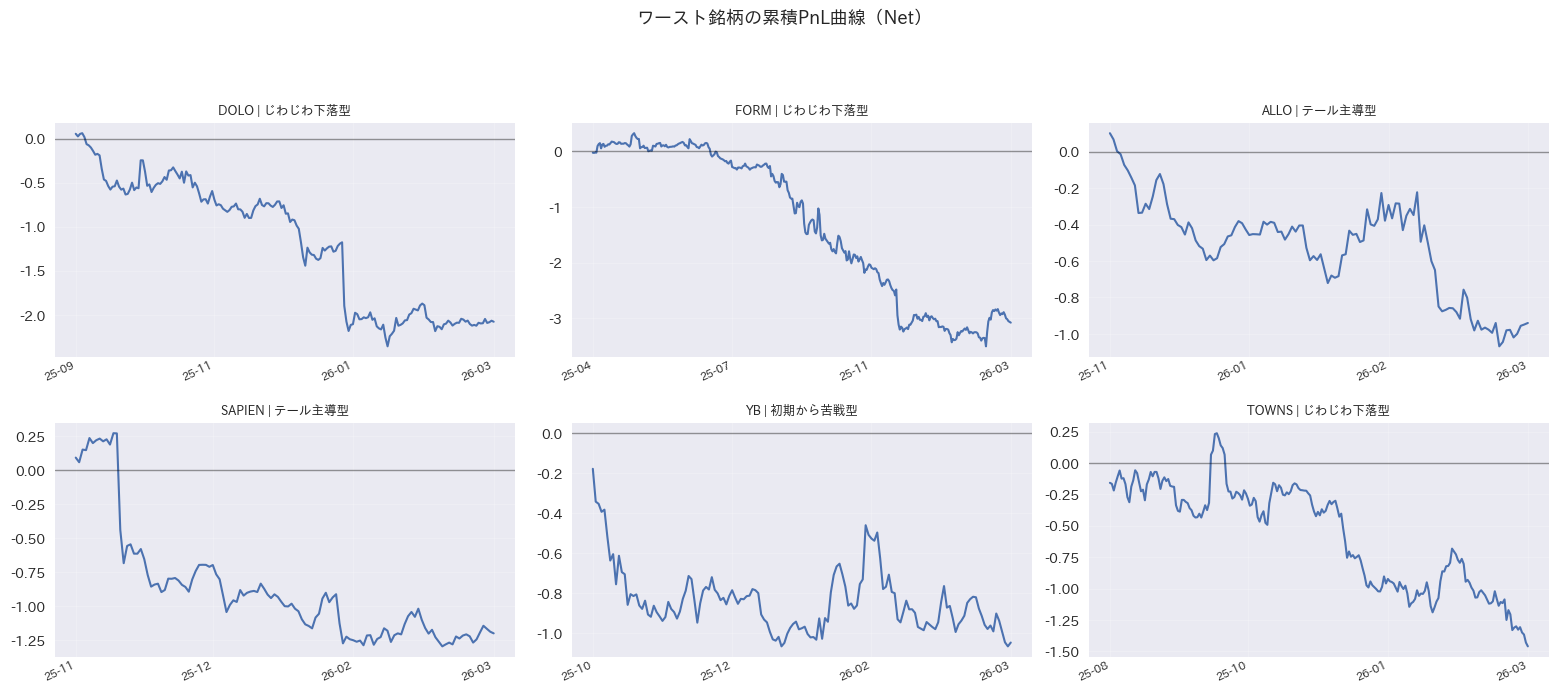

,rank,graph_target,symbol,failure_type,sharpe_net,return_net,dd_net,peak_date,trough_date,peak_to_trough_days,peak_to_trough_drop
0,1,図あり,DOLO,じわじわ下落型,-2.482389,-2.076353,-2.416122,2025-09-13,2026-02-01,141,-2.416122
1,2,図あり,FORM,じわじわ下落型,-2.295651,-3.078633,-3.828823,2025-05-07,2026-03-01,298,-3.828823
2,3,図あり,ALLO,テール主導型,-2.195613,-0.939763,-1.168663,2025-11-25,2026-03-14,109,-1.168663
3,4,図あり,SAPIEN,テール主導型,-2.161007,-1.200517,-1.569265,2025-12-01,2026-03-07,96,-1.569265
4,5,図あり,YB,初期から苦戦型,-2.130616,-1.045688,-0.886939,2025-10-29,2026-03-21,143,-0.886939
5,6,図あり,TOWNS,じわじわ下落型,-2.065411,-1.459767,-1.696293,2025-10-13,2026-03-22,160,-1.696293
6,7,表のみ,RARE,じわじわ下落型,-2.058167,-3.807392,-3.871850,2024-11-04,2026-03-22,503,-3.871850
7,8,表のみ,MITO,じわじわ下落型,-1.983425,-1.465201,-1.729860,2025-10-18,2026-03-22,155,-1.729860
8,9,表のみ,EUL,じわじわ下落型,-1.947229,-1.017220,-1.060733,2025-10-27,2026-03-16,140,-1.060733
9,10,表のみ,AWE,初期から苦戦型,-1.888920,-1.512891,-1.570633,2025-06-04,2026-02-26,267,-1.570633


この図と表からわかること: 一撃型の損失（tail_loss_ratio>=0.5）は5銘柄で、それ以外はじわじわ負ける形が多いです。
補足: 図はワースト上位6銘柄、7位以下は表で peak_date（高値日）→ trough_date（底日）を確認できます。


In [124]:
plot_top_n = 6
fig = plot_worst_curves(artifacts, max_cols=3, top_n=plot_top_n)
plt.show()

worst_df = artifacts["worst_diagnostics"].copy()
worst_table = build_worst_summary_table(artifacts, top_n_plot=plot_top_n)
display(worst_table)

tail_heavy = int((worst_df["tail_loss_ratio"].fillna(0) >= 0.5).sum())
print(
    f"この図と表からわかること: 一撃型の損失（tail_loss_ratio>=0.5）は{tail_heavy}銘柄で、"
    f"それ以外はじわじわ負ける形が多いです。"
)
print("補足: 図はワースト上位6銘柄、7位以下は表で peak_date（高値日）→ trough_date（底日）を確認できます。")


### 宿題2 追加検証: 主因タイプと補助タグの定義
混乱を避けるために、「主因タイプ（1銘柄1つ）」と「補助タグ（重複可）」を分けます。

**主因タイプ（優先順位で1つに決める）**
- `コスト負け型`: `sharpe_gross > 0` かつ `sharpe_net <= 0`
- `初期から苦戦型`: `peak_cum_net <= 0`
- `テール主導型`: `tail_loss_ratio >= 0.5`
- `じわじわ下落型`: `peak_to_trough_days >= 90` かつ `tail_loss_ratio < 0.5`
- `方向不一致型`: `corr_zscore_next > 0`
- `その他`

**補助タグ（重複可）**
- `方向不一致`: `corr_zscore_next > 0`
- `テール主導`: `tail_loss_ratio >= 0.5`
- `じわじわ下落`: `peak_to_trough_days >= 90` かつ `tail_loss_ratio < 0.5`
- `初期から苦戦`: `peak_cum_net <= 0`


,観点,ワースト群,全体
0,方向不一致率（corr_zscore_next > 0）,95.0,51.10
1,コスト負け率（gross>0 かつ net<=0）,0.0,6.35
2,テール主導率（tail_loss_ratio >= 0.5）,25.0,NaN


この表からわかること: ワースト20銘柄では方向不一致率が95.00%と高く、コスト負け率は0.00%、テール主導率は25.00%でした。


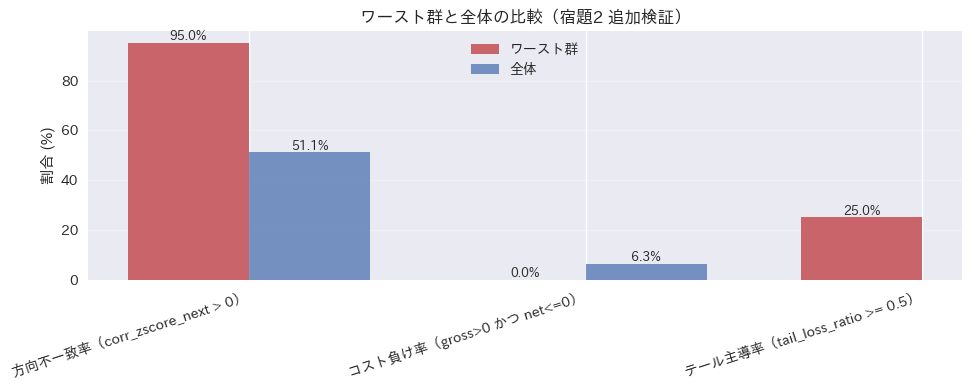

In [125]:
worst_n = int(artifacts["config"].get("worst_n", 20))
worst_df = artifacts["worst_diagnostics"].copy().sort_values("sharpe_net").head(worst_n)
summary_df_all = artifacts["input_summary"].copy()

decomp = pd.DataFrame([
    {
        "観点": "方向不一致率（corr_zscore_next > 0）",
        "ワースト群": (worst_df["corr_zscore_next"] > 0).mean() * 100,
        "全体": (summary_df_all["corr_zscore_next"] > 0).mean() * 100,
    },
    {
        "観点": "コスト負け率（gross>0 かつ net<=0）",
        "ワースト群": ((worst_df["sharpe_gross"] > 0) & (worst_df["sharpe_net"] <= 0)).mean() * 100,
        "全体": ((summary_df_all["sharpe_gross"] > 0) & (summary_df_all["sharpe_net"] <= 0)).mean() * 100,
    },
    {
        "観点": "テール主導率（tail_loss_ratio >= 0.5）",
        "ワースト群": (worst_df["tail_loss_ratio"] >= 0.5).mean() * 100,
        "全体": np.nan,
    },
])

decomp["ワースト群"] = decomp["ワースト群"].round(2)
decomp["全体"] = decomp["全体"].round(2)
display(decomp)

dir_rate = float(decomp.loc[decomp["観点"] == "方向不一致率（corr_zscore_next > 0）", "ワースト群"].iloc[0])
cost_rate = float(decomp.loc[decomp["観点"] == "コスト負け率（gross>0 かつ net<=0）", "ワースト群"].iloc[0])
tail_rate = float(decomp.loc[decomp["観点"] == "テール主導率（tail_loss_ratio >= 0.5）", "ワースト群"].iloc[0])

print(
    f"この表からわかること: ワースト{worst_n}銘柄では方向不一致率が{dir_rate:.2f}%と高く、"
    f"コスト負け率は{cost_rate:.2f}%、テール主導率は{tail_rate:.2f}%でした。"
)


# 可視化: ワースト群と全体の率比較（初心者向けに結論を一目化）
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(decomp))
width = 0.36

worst_vals = decomp["ワースト群"].astype(float).to_numpy()
all_vals = pd.to_numeric(decomp["全体"], errors="coerce").to_numpy()

ax.bar(x - width / 2, worst_vals, width=width, color="#C44E52", alpha=0.85, label="ワースト群")
ax.bar(x + width / 2, all_vals, width=width, color="#4C72B0", alpha=0.75, label="全体")

for i, v in enumerate(worst_vals):
    if np.isfinite(v):
        ax.text(i - width / 2, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(all_vals):
    if np.isfinite(v):
        ax.text(i + width / 2, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(decomp["観点"], rotation=18, ha="right")
ax.set_ylabel("割合 (%)")
ax.set_title("ワースト群と全体の比較（宿題2 追加検証）")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


### 宿題2 追加検証: いつ下がるか（時系列）
ここでは、各ワースト銘柄の `peak_date -> trough_date` を出して、下落の進み方を確認します。


,symbol,peak_date,trough_date,peak_to_trough_days,peak_to_trough_drop,worst1d_event_day,tail_loss_ratio,corr_zscore_next
13,WIF,2024-07-17,2026-02-05,568,-5.440229,584,0.136959,0.042489
12,PNUT,2025-02-01,2026-03-21,413,-5.076548,179,0.299247,0.110567
14,METIS,2024-03-30,2025-03-30,365,-4.683629,31,0.127488,0.053846
6,RARE,2024-11-04,2026-03-22,503,-3.871850,206,0.227538,0.110796
1,FORM,2025-05-07,2026-03-01,298,-3.828823,272,0.226153,0.064033
17,COS,2024-11-09,2026-03-18,494,-3.335623,530,0.518085,0.081850
10,RENDER,2024-08-09,2026-02-02,542,-3.263441,441,0.157274,0.054050
11,KERNEL,2025-06-19,2025-12-03,167,-2.702406,179,0.262391,0.042406
0,DOLO,2025-09-13,2026-02-01,141,-2.416122,138,0.464106,0.117709
19,STO,2025-08-11,2026-03-22,223,-2.037490,260,0.612748,0.165335


,指標,中央値,25%,75%
0,peak_event_day,37.0,14.0,72.0
1,trough_event_day,298.0,157.8,411.0
2,peak_to_trough_days,195.0,142.5,377.0
3,worst1d_event_day,158.5,69.8,272.5


この結果からわかること: ワースト銘柄は上場初期にピークを作った後、中長期でじわじわ悪化するケースが多いです。


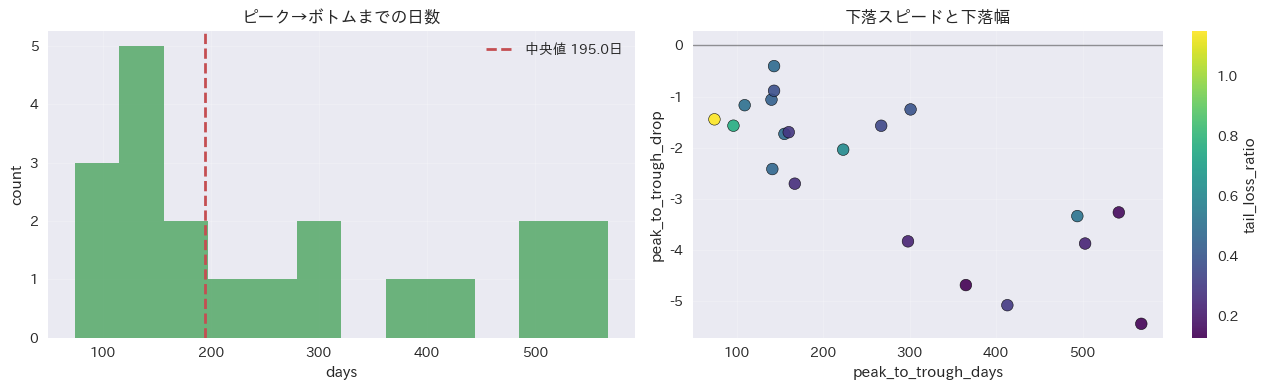

In [126]:
daily_df_all = artifacts["input_daily"].copy()
daily_df_all["date"] = pd.to_datetime(daily_df_all["date"], errors="coerce", utc=True).dt.tz_convert(None)

timing_rows = []
for sym in worst_df["symbol"].astype(str):
    d = daily_df_all[daily_df_all["symbol"] == sym].dropna(subset=["date"]).sort_values("date").copy()
    if d.empty:
        continue
    d["cum_net"] = d["pnl_net"].cumsum()
    peak_pos = int(d["cum_net"].values.argmax())
    trough_pos = int(d["cum_net"].values.argmin())
    w1_pos = int(d["pnl_net"].values.argmin())

    peak = d.iloc[peak_pos]
    trough = d.iloc[trough_pos]
    worst1d = d.iloc[w1_pos]

    timing_rows.append({
        "symbol": sym,
        "peak_date": peak["date"].date().isoformat(),
        "peak_event_day": int(peak["event_day"]),
        "trough_date": trough["date"].date().isoformat(),
        "trough_event_day": int(trough["event_day"]),
        "peak_to_trough_days": int((trough["date"] - peak["date"]).days),
        "peak_to_trough_drop": float(trough["cum_net"] - peak["cum_net"]),
        "worst1d_event_day": int(worst1d["event_day"]),
        "worst1d_net": float(worst1d["pnl_net"]),
        "peak_cum_net": float(peak["cum_net"]),
        "tail_loss_ratio": float(worst_df.loc[worst_df["symbol"] == sym, "tail_loss_ratio"].iloc[0]),
        "corr_zscore_next": float(worst_df.loc[worst_df["symbol"] == sym, "corr_zscore_next"].iloc[0]),
    })

timing_df = pd.DataFrame(timing_rows).sort_values("peak_to_trough_drop")
display(timing_df[[
    "symbol", "peak_date", "trough_date", "peak_to_trough_days",
    "peak_to_trough_drop", "worst1d_event_day", "tail_loss_ratio", "corr_zscore_next"
]])

summary_stats = pd.DataFrame({
    "指標": ["peak_event_day", "trough_event_day", "peak_to_trough_days", "worst1d_event_day"],
    "中央値": [
        timing_df["peak_event_day"].median(),
        timing_df["trough_event_day"].median(),
        timing_df["peak_to_trough_days"].median(),
        timing_df["worst1d_event_day"].median(),
    ],
    "25%": [
        timing_df["peak_event_day"].quantile(0.25),
        timing_df["trough_event_day"].quantile(0.25),
        timing_df["peak_to_trough_days"].quantile(0.25),
        timing_df["worst1d_event_day"].quantile(0.25),
    ],
    "75%": [
        timing_df["peak_event_day"].quantile(0.75),
        timing_df["trough_event_day"].quantile(0.75),
        timing_df["peak_to_trough_days"].quantile(0.75),
        timing_df["worst1d_event_day"].quantile(0.75),
    ],
})
summary_stats[["中央値", "25%", "75%"]] = summary_stats[["中央値", "25%", "75%"]].round(1)
display(summary_stats)

print(
    "この結果からわかること: ワースト銘柄は上場初期にピークを作った後、"
    "中長期でじわじわ悪化するケースが多いです。"
)


# 可視化: 下落までの日数分布と、下落スピード×下落幅
if len(timing_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    days = timing_df["peak_to_trough_days"].dropna()
    bins = min(12, max(5, len(days)))
    axes[0].hist(days, bins=bins, color="#55A868", alpha=0.85)
    if len(days) > 0:
        axes[0].axvline(days.median(), color="#C44E52", linestyle="--", linewidth=2, label=f"中央値 {days.median():.1f}日")
        axes[0].legend()
    axes[0].set_title("ピーク→ボトムまでの日数")
    axes[0].set_xlabel("days")
    axes[0].set_ylabel("count")
    axes[0].grid(alpha=0.2)

    sc = axes[1].scatter(
        timing_df["peak_to_trough_days"],
        timing_df["peak_to_trough_drop"],
        c=timing_df["tail_loss_ratio"],
        cmap="viridis",
        s=70,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.4,
    )
    axes[1].axhline(0, color="black", linewidth=1, alpha=0.4)
    axes[1].set_title("下落スピードと下落幅")
    axes[1].set_xlabel("peak_to_trough_days")
    axes[1].set_ylabel("peak_to_trough_drop")
    axes[1].grid(alpha=0.2)
    cbar = fig.colorbar(sc, ax=axes[1])
    cbar.set_label("tail_loss_ratio")

    fig.tight_layout()
    plt.show()


### 宿題2 追加検証: 主因タイプと補助タグの集計
ここでは、主因タイプ（単一ラベル）と補助タグ（重複可）を分けて集計し、改善案につなげます。


,主因タイプ,count
0,じわじわ下落型,10
1,テール主導型,5
2,初期から苦戦型,5


,補助タグ,割合(%)
0,方向不一致,95.0
1,テール主導,25.0
2,じわじわ下落,75.0
3,初期から苦戦,25.0


,symbol,主因タイプ,補助タグ,sharpe_net,return_net
0,DOLO,じわじわ下落型,方向不一致/じわじわ下落,-2.482389,-2.076353
1,FORM,じわじわ下落型,方向不一致/じわじわ下落,-2.295651,-3.078633
2,ALLO,テール主導型,方向不一致/テール主導,-2.195613,-0.939763
3,SAPIEN,テール主導型,方向不一致/テール主導,-2.161007,-1.200517
4,YB,初期から苦戦型,じわじわ下落/初期から苦戦,-2.130616,-1.045688
5,TOWNS,じわじわ下落型,方向不一致/じわじわ下落,-2.065411,-1.459767
6,RARE,じわじわ下落型,方向不一致/じわじわ下落,-2.058167,-3.807392
7,MITO,じわじわ下落型,方向不一致/じわじわ下落,-1.983425,-1.465201
8,EUL,じわじわ下落型,方向不一致/じわじわ下落,-1.947229,-1.017220
9,AWE,初期から苦戦型,方向不一致/じわじわ下落/初期から苦戦,-1.888920,-1.512891


,検証案,内容
0,方向不一致フィルタ,corr_zscore_nextが正の銘柄/期間では逆張りを停止 or ロット縮小
1,テール損失ストッパー,5日累積損失が閾値超えで一定期間トレード停止
2,上場後日数フィルタ,event_day帯ごとに許可/不許可を分ける


この結果からわかること: 主因タイプは『じわじわ下落型』が中心で、補助タグでは『方向不一致』が高頻度です。


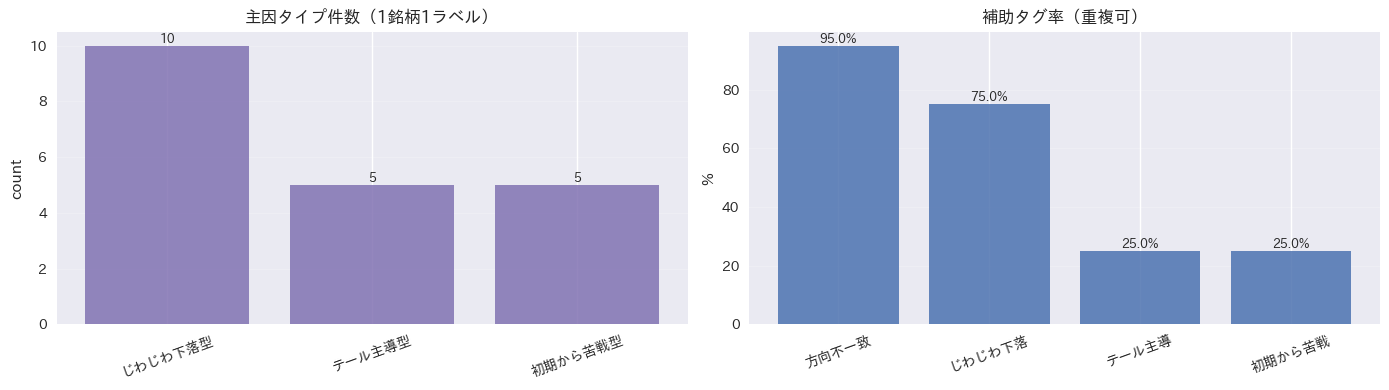

In [127]:
worst_df = artifacts["worst_diagnostics"].copy()
required_cols = {"primary_loss_type", "loss_tags", "peak_to_trough_days", "peak_cum_net"}
if not required_cols.issubset(worst_df.columns):
    try:
        import importlib
        import homework_report_common as _hrc

        _hrc = importlib.reload(_hrc)
        if {"summary_df", "daily_df", "REPORT_CONFIG"}.issubset(globals()):
            artifacts = _hrc.run_homework_report(summary_df, daily_df, REPORT_CONFIG)
            worst_df = artifacts["worst_diagnostics"].copy()
            print("[補足] 旧形式データを検出したため、最新版ロジックで再集計しました。")
    except Exception as e:
        print(f"[補足] 再集計に失敗したため、互換補完で続行します: {e}")

if "_ensure_primary_loss_columns" not in globals():
    def _ensure_primary_loss_columns(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        if "primary_loss_type" not in out.columns:
            legacy_map = {
                "逆張り不適合型": "方向不一致型",
                "恒常負け型": "その他",
                "テール損失集中型": "テール主導型",
                "コスト負け型": "コスト負け型",
            }
            if "failure_type" in out.columns:
                out["primary_loss_type"] = out["failure_type"].map(legacy_map).fillna(out["failure_type"])
            else:
                out["primary_loss_type"] = "その他"
        for c in ["corr_zscore_next", "tail_loss_ratio", "peak_to_trough_days", "peak_cum_net"]:
            if c not in out.columns:
                out[c] = np.nan
        if "loss_tags" not in out.columns:
            def _mk_tags(r: pd.Series) -> str:
                tags = []
                if pd.notna(r["corr_zscore_next"]) and r["corr_zscore_next"] > 0:
                    tags.append("方向不一致")
                if pd.notna(r["tail_loss_ratio"]) and r["tail_loss_ratio"] >= 0.5:
                    tags.append("テール主導")
                if (
                    pd.notna(r["peak_to_trough_days"]) and pd.notna(r["tail_loss_ratio"]) and
                    (r["peak_to_trough_days"] >= 90) and (r["tail_loss_ratio"] < 0.5)
                ):
                    tags.append("じわじわ下落")
                if pd.notna(r["peak_cum_net"]) and r["peak_cum_net"] <= 0:
                    tags.append("初期から苦戦")
                return "/".join(tags if tags else ["その他"])
            out["loss_tags"] = out.apply(_mk_tags, axis=1)
        return out

worst_df = _ensure_primary_loss_columns(worst_df)

main_count = worst_df["primary_loss_type"].value_counts().reset_index()
main_count.columns = ["主因タイプ", "count"]
display(main_count)

tag_rate = pd.DataFrame([
    {"補助タグ": "方向不一致", "割合(%)": (worst_df["corr_zscore_next"] > 0).mean() * 100},
    {"補助タグ": "テール主導", "割合(%)": (worst_df["tail_loss_ratio"] >= 0.5).mean() * 100},
    {
        "補助タグ": "じわじわ下落",
        "割合(%)": ((worst_df["peak_to_trough_days"] >= 90) & (worst_df["tail_loss_ratio"] < 0.5)).mean() * 100,
    },
    {"補助タグ": "初期から苦戦", "割合(%)": (worst_df["peak_cum_net"] <= 0).mean() * 100},
])
tag_rate["割合(%)"] = tag_rate["割合(%)"].round(2)
display(tag_rate)

detail = (
    worst_df[["symbol", "primary_loss_type", "loss_tags", "sharpe_net", "return_net"]]
    .rename(columns={"primary_loss_type": "主因タイプ", "loss_tags": "補助タグ"})
)
display(detail.sort_values("sharpe_net"))

rule_ideas = pd.DataFrame([
    {"検証案": "方向不一致フィルタ", "内容": "corr_zscore_nextが正の銘柄/期間では逆張りを停止 or ロット縮小"},
    {"検証案": "テール損失ストッパー", "内容": "5日累積損失が閾値超えで一定期間トレード停止"},
    {"検証案": "上場後日数フィルタ", "内容": "event_day帯ごとに許可/不許可を分ける"},
])
display(rule_ideas)

print(
    "この結果からわかること: 主因タイプは『じわじわ下落型』が中心で、"
    "補助タグでは『方向不一致』が高頻度です。"
)


# 可視化: 主因タイプ件数と補助タグ率
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

main_plot = main_count.sort_values("count", ascending=False).copy()
axes[0].bar(main_plot["主因タイプ"], main_plot["count"], color="#8172B2", alpha=0.85)
for i, v in enumerate(main_plot["count"].to_numpy()):
    axes[0].text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("主因タイプ件数（1銘柄1ラベル）")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.2)

tag_plot = tag_rate.sort_values("割合(%)", ascending=False).copy()
axes[1].bar(tag_plot["補助タグ"], tag_plot["割合(%)"], color="#4C72B0", alpha=0.85)
for i, v in enumerate(tag_plot["割合(%)"].to_numpy()):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_title("補助タグ率（重複可）")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()


---
## 出力CSV保存
配布・再利用用のCSVと `manifest.json` を保存します。

In [128]:
exported = export_artifacts(artifacts, CSV_OUT_DIR)
print("保存完了ファイル")
for k, v in exported.items():
    print(f"- {k}: {v}")

print("\nこの結果からわかること: ここで保存したCSVを使えば、次のレポートノートで同じ結果を再現できます。")


保存完了ファイル
- input_summary: homework_input_summary.csv
- input_daily: homework_input_daily.csv
- curve_eventday_summary: altcoin_basis_hw_post_listing_curve_14_59_eventday_summary.csv
- curve_symbol_daily: altcoin_basis_hw_post_listing_curve_14_59_symbol_daily.csv
- curve_symbol_month: altcoin_basis_hw_post_listing_curve_14_59_symbol_month.csv
- window_symbol_metrics: altcoin_basis_hw_post_listing_window_symbol_metrics.csv
- window_summary: altcoin_basis_hw_post_listing_window_summary.csv
- paired_diff: altcoin_basis_hw_post_listing_paired_diff.csv
- worst_diagnostics: altcoin_basis_hw_worst_diagnostics.csv
- manifest: manifest.json

この結果からわかること: ここで保存したCSVを使えば、次のレポートノートで同じ結果を再現できます。


---
## 最終まとめ
ここでは、宿題1・宿題2（追加検証含む）の結果を初心者向けに「結論→根拠→次アクション」の順で整理します。


In [129]:
import importlib
import homework_report_common as _hrc

_hrc = importlib.reload(_hrc)
artifacts = _hrc.run_homework_report(summary_df, daily_df, REPORT_CONFIG)
_hrc.print_final_homework_answer(artifacts)


最終まとめ（初心者向け）
1) 先に結論（30秒版）
- 宿題1: day14-59の累積中央値はプラスだが、銘柄差が大きく全銘柄で安定とは言えない。
- 宿題2: 主因タイプは『じわじわ下落型』が最多（10/20銘柄, 50.00%）。
- 補助タグでは『方向不一致』が高頻度で、単発ショックより中長期のじわじわ悪化が多い。
- 判定: 今回は採用しない（上場直後優位の恒常性は確認できず）

2) 宿題1の結果（上場後2ヶ月: event_day 14-59）
- day14開始の理由: z-scoreを14日で作るため、day0-13は比較が安定しない。
- 1ヶ月目（day14-29）中央値: +0.0462
- 2ヶ月目（day30-59）中央値: +0.0074
- day59累積中央値: +0.0662
- 最終日の銘柄差（10-90%幅）: +1.3482
- 読み方: 中央値が勝っても、銘柄差が広いと一部で大きく負ける。

3) 宿題2の結果（追加検証を反映）
- 対象: sharpe_net下位20銘柄（Sharpeは成績の安定度）
- 負け方の分解: 方向不一致 95.00%（全体 51.10%） / コスト負け 0.00%（全体 6.35%） / テール主導 25.00%
- いつ下がるか（中央値）: peak 37.0日 -> trough 298.0日 （peak->trough 195.0日、worst1d 158.5日）
- じわじわ下落率（peak_to_trough_days>=90 かつ tail<0.5）: 75.00%
- 初期から苦戦率（peak_cum_net<=0）: 25.00%
- 主因タイプ内訳（1銘柄1ラベル）:
  - じわじわ下落型: 10銘柄
  - テール主導型: 5銘柄
  - 初期から苦戦型: 5銘柄
- 補助タグ率（重複可）:
  - 方向不一致: 95.00%
  - テール主導: 25.00%
  - じわじわ下落: 75.00%
  - 初期から苦戦: 25.00%

4) 判定の根拠（反論チェック込み）
- 判定した仮説: 上場直後（early=30-89日）の方が後半（late=120-179日）より有利
- ルールA: 上場初期−後半の中央値差がプラス
  実測 +0.0156 -> 達成